# 4. How surface melt changes the grounding-zone flux

The first three notebooks built a model of Nivlisen that reproduces the observed flow (inverting for friction and fluidity). Here we use that calibrated model to ask a new question connected to grounding zone flux sensitivity:

> if surface meltwater is produced somewhere on the ice, how much does the
> **grounding-zone flux** — the ice discharge across the grounding line —
> change in response?

Two ingredients combine into one map:

1. **Sensitivity to thinning.** Using the *adjoint* of the flow model we get, in a single solve, how the grounding-zone flux responds to thinning the ice by 1 m at *every* point at once — $\partial Q_{GL}/\partial h$.
2. **meltwater routing.** Surface water does not thin the ice where it is produced; it runs downhill along the surface and pools in hydropotential lows. We route it with **Fill-Spill-Merge** (Barnes et al., 2020) down the ice *surface* — which, for supraglacial water, *is* the hydraulic potential.

Combining these methods gives the **grounding-zone-flux sensitivity to surface melt**: melt of 1 m anywhere in the domain, and its effect on the discharge, *after* the
water has been routed. Comparing the routed answer with the naive "melt-thins-in-place" answer shows how surface meltwater rerouting affects the glacier's response to ocean forcing.

## Setup: load the calibrated model

We reload everything notebook 2 saved to `../output/inversion.h5` — the mesh,
the inferred log-friction $\theta$ and log-fluidity $\varphi$, the geometry,
and the grounded mask — and rebuild the same icepack shallow-stream model at
the optimum.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import firedrake as fd
from firedrake import Constant, Function, exp, assemble, dx, inner, grad
import firedrake.adjoint as fda
import icepack

import nivlisen_tutorial as nt

with fd.CheckpointFile("../output/inversion.h5", "r") as chk:
    mesh = chk.load_mesh()
    theta = chk.load_function(mesh, "log_friction")
    phi = chk.load_function(mesh, "log_fluidity")
    h = chk.load_function(mesh, "thickness")
    s = chk.load_function(mesh, "surface")
    grounded = chk.load_function(mesh, "grounded")
    u_obs = chk.load_function(mesh, "u_obs")

Q = fd.FunctionSpace(mesh, "CG", 1)
V = fd.VectorFunctionSpace(mesh, "CG", 1)
INFLOW, CALVING = [1], [2]
print(f"mesh: {mesh.num_vertices()} vertices, {mesh.num_cells()} cells")

A0 = Constant(float(icepack.rate_factor(Constant(260.0))), domain=mesh)
C0 = Constant(0.01, domain=mesh)
solver = nt.make_solver(dirichlet_ids=INFLOW, ice_front_ids=CALVING)

def simulation(thickness):
    """Forward SSA solve at the inferred controls, for a given thickness."""
    A = Function(Q).interpolate(A0 * exp(phi))
    C = Function(Q).interpolate(C0 * exp(theta * grounded))
    return solver.diagnostic_solve(velocity=u_obs, thickness=thickness,
                                   surface=s, fluidity=A, friction=C)

/home/firedrake/firedrake/lib/python3.12/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


mesh: 2151 vertices, 4061 cells


/home/firedrake/firedrake/src/firedrake/firedrake/constant.py:73: FutureWarning: Giving Constants a domain is no longer supported. Instead please create a Function in the Real space.
  warnings.warn(


## The grounding-zone flux

We measure the flux across the grounding line without ever tracing the line itself, using a divergence trick. For a grounded indicator $\chi$ (1 on grounded ice, 0 on the shelf), $\nabla\chi$ is a narrow ridge sitting exactly
on the flotation contour, so

$$ Q_{GL} = \int h\,\mathbf u\cdot\nabla\chi \; dx $$

collects $h\,\mathbf u\cdot\hat n$ across the grounding line. `nt.grounding_line_gate` builds a smooth $\chi$ from the flotation criterion; the flux is signed (negative = outflow), and $\times$ `nt.ICE_TO_GT` converts m³/yr to Gt/yr.

In [2]:
gate = nt.grounding_line_gate(h, s, Q, length=4000.0)
u_map = simulation(h)
Q_GL = float(nt.grounding_zone_flux(u_map, h, gate))
discharge = abs(Q_GL) * nt.ICE_TO_GT
print(f"grounding-zone flux Q_GL = {Q_GL:.3e} m³/yr  →  discharge {discharge:.2f} Gt/yr")

grounding-zone flux Q_GL = -3.911e+09 m³/yr  →  discharge 3.59 Gt/yr


## Sensitivity to thinning, by the adjoint

We want $\partial Q_{GL}/\partial h$: how the flux changes when the ice thins. The adjoint method gives the whole field — the response to a 1 m perturbation at *every* node — from a single linearised solve. We tape one forward solve with `firedrake.adjoint`, treating the **thickness** as the control (the grounded mask is frozen at its reference value, so we measure the flux through the fixed reference grounding line, not its migration), then ask for the gradient of the flux in the cotangent space (`riesz_representation=None`) so it is the raw $\partial Q_{GL}/\partial h_i$ per node.

In [3]:
fda.continue_annotation()
h_c = h.copy(deepcopy=True)
u_c = simulation(h_c)
J = nt.grounding_zone_flux(u_c, h_c, gate)          # signed flux, taped
rf = fda.ReducedFunctional(J, fda.Control(h_c))
fda.pause_annotation()

dJdh = rf.derivative(options={"riesz_representation": None})
g_raw = np.asarray(dJdh.dat.data_ro).copy()          # raw dual ∂Q_GL/∂h_i (m³/yr per m)

# discharge D = |Q_GL| = -Q_GL (outflow), so ∂D/∂h = -g_raw; 1 m of *thinning*
# (δh = -1) changes discharge by +g_raw. Report in Gt/yr.
dD_thinning = g_raw * nt.ICE_TO_GT
print(f"discharge response to 1 m thinning (Gt/yr): "
      f"min={dD_thinning.min():.2e}  max={dD_thinning.max():.2e}")

discharge response to 1 m thinning (Gt/yr): min=-4.72e-04  max=4.49e-06


A finite-difference check in a smooth direction (uniform thinning) confirms the adjoint: its directional derivative matches a *converged* finite difference to about 2%. The small residual comes from the **non-smooth** flotation term in the friction law right at the grounding line (a formal Taylor test converges at first order, not second). A couple of percent is immaterial for the sensitivity map.

In [4]:
v = Function(Q).interpolate(Constant(1.0))           # uniform-thinning direction
adj_dd = float(np.dot(g_raw, v.dat.data_ro))         # adjoint directional derivative
J0 = float(nt.grounding_zone_flux(simulation(h), h, gate))
eps = 1e-3
h_eps = Function(Q).interpolate(h + Constant(eps) * v)
fd_dd = (float(nt.grounding_zone_flux(simulation(h_eps), h_eps, gate)) - J0) / eps
print(f"directional derivative — adjoint {adj_dd:.3e}  vs finite-diff {fd_dd:.3e}  "
      f"(agree to {abs(adj_dd - fd_dd)/abs(fd_dd):.1%})")

directional derivative — adjoint -3.955e+07  vs finite-diff -3.894e+07  (agree to 1.6%)


The grounding zone flux sensitivity, to leading order, is set by thinning at the grounding zone which lowers the discharge (blue). It is near zero in the slow interior, where
the velocity barely depends on thickness.

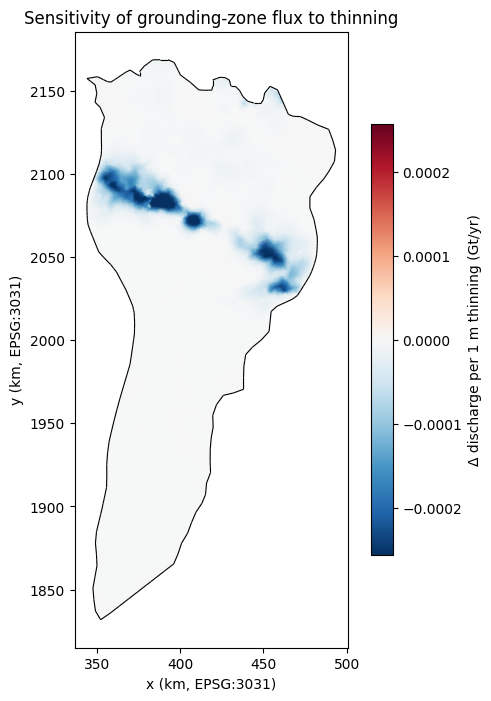

In [5]:
fig, ax = plt.subplots(figsize=(6, 8))
f_dD = Function(Q, name="dD_thinning"); f_dD.dat.data[:] = dD_thinning
m = float(np.percentile(np.abs(dD_thinning), 99)) or 1.0
c = nt.plot_field(f_dD, ax, cmap="RdBu_r", vmin=-m, vmax=m)
fig.colorbar(c, ax=ax, shrink=0.7, label="Δ discharge per 1 m thinning (Gt/yr)")
ax.set_title("Sensitivity of grounding-zone flux to thinning")
plt.show()

## Where does the meltwater go? Routing with Fill-Spill-Merge

Surface meltwater flows down the ice **surface** and either pools in surface
depressions or drains off the ice edge. We rasterise the surface elevation,
mark everything off the ice as an ocean drain, and route with the compiled
`fsm_wrapper` (Fill-Spill-Merge). As a demonstration we route a uniform 1 m of
melt over the whole ice surface: most of it drains away, a little pools.

routing grid (1683, 747) @ 200 m, 697412 ice cells
uniform 1 m melt: 2.79e+10 m³ in, 7.56e+09 m³ pooled, 2.03e+10 m³ drained off the ice


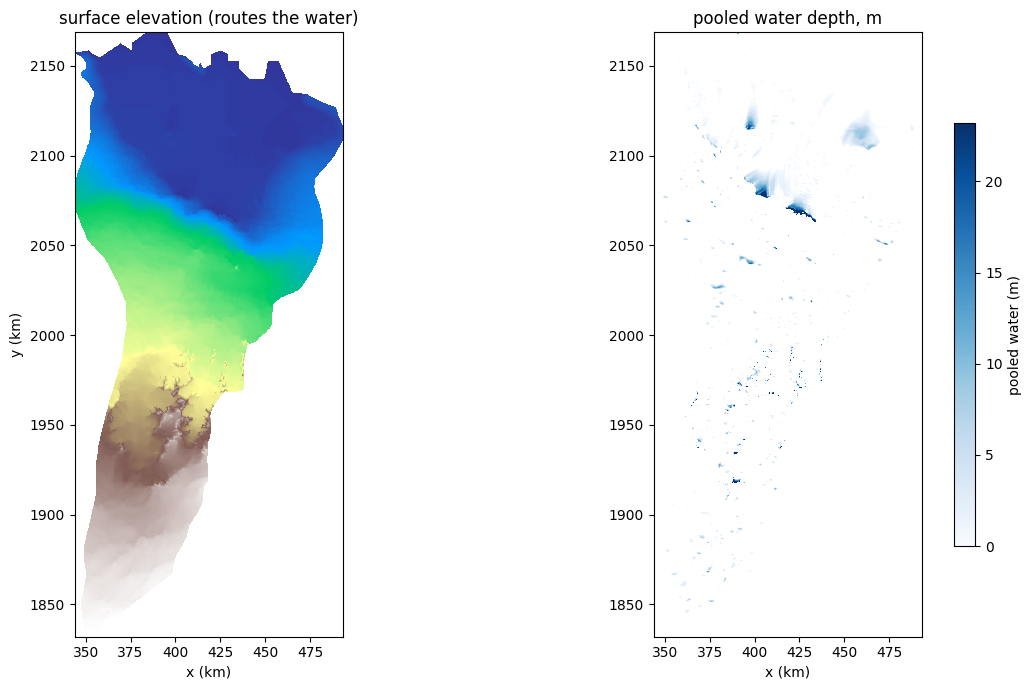

In [6]:
ds = nt.load_data("../data/nivlisen_data.nc")
domain, basin, neighbours = nt.load_domain("../data/nivlisen_domain.gpkg")
ice_poly = nt.ice_extent(ds, domain)

fe_coords = Function(V).interpolate(mesh.coordinates).dat.data_ro
RES = 200.0
dem, xs, ys, inside = nt.routing_grid_rema(
    "../data/nivlisen_surface_rema_200m.tif", fe_coords, ice_poly)
nn = nt.grid_node_map(xs, ys, fe_coords)             # cell → nearest node (precomputed once)
print(f"routing grid {dem.shape} @ {RES:.0f} m, {int(inside.sum())} ice cells")

win = np.where(inside, 1.0, 0.0)
wout = nt.route_fsm(dem, win)
pooled = np.where(inside & (wout > 1e-6), wout, np.nan)   # where water collects
area = RES * RES
print(f"uniform 1 m melt: {win.sum()*area:.2e} m³ in, "
      f"{wout[inside].sum()*area:.2e} m³ pooled, "
      f"{(win.sum()-wout[inside].sum())*area:.2e} m³ drained off the ice")

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].pcolormesh(xs/1e3, ys/1e3, np.where(dem > -9990, dem, np.nan), cmap="terrain")
axes[0].set_title("surface elevation (routes the water)")
vmax = float(np.nanpercentile(pooled, 98)) if np.isfinite(pooled).any() else 1.0
p = axes[1].pcolormesh(xs/1e3, ys/1e3, pooled, cmap="Blues", vmin=0, vmax=vmax)
axes[1].set_title("pooled water depth, m")
fig.colorbar(p, ax=axes[1], shrink=0.7, label="pooled water (m)")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")
fig.tight_layout(); plt.show()

## The melt-sensitivity map

For melt produced at each node we route the water, express the result as a thickness change $\delta h$ on the mesh, and dot it with the adjoint sensitivity:

$$ S(\mathbf x)=-\,\texttt{ICE\_TO\_GT}\;\sum_i \frac{\partial Q_{GL}}{\partial h_i}\,\delta h_i(\mathbf x), $$

the change in grounding-zone discharge per 1 m of melt at $\mathbf x$ (a plain dual pairing — the raw adjoint gradient dotted with the routed thickness change). The **routed** map uses $\delta h$ from Fill-Spill-Merge; the **unrouted** map is the naive assumption that melt just thins the ice where it
falls ($\delta h=-1$ locally), which is exactly the thinning sensitivity above.

In [7]:
N = Q.dim()
sens_routed = np.zeros(N)
t0 = time.time()
with nt.FSMRouter(dem) as router:
    for k in range(N):
        win_k = np.where((nn == k) & inside, 1.0, 0.0)
        if win_k.sum() == 0:                          # node owns no grid cell
            continue
        wout_k = router.route(win_k)
        redist_k = nt.grid_to_nodes(np.where(inside, wout_k - win_k, 0.0), nn, inside, N)
        sens_routed[k] = -nt.ICE_TO_GT * float(np.dot(g_raw, redist_k))
        if (k + 1) % 400 == 0:
            print(f"  routed {k+1}/{N} nodes ({time.time()-t0:.0f}s)")
sens_unrouted = g_raw * nt.ICE_TO_GT                  # melt thins in place
print(f"routed map done in {time.time()-t0:.0f}s")

  routed 400/2151 nodes (15s)


  routed 800/2151 nodes (31s)


  routed 1200/2151 nodes (46s)


  routed 1600/2151 nodes (62s)


  routed 2000/2151 nodes (77s)


routed map done in 83s


Routed versus unrouted, side by side. The difference is the fingerprint of surface hydrology: melt produced up-glacier is delivered downslope before it thins the ice, so the sensitivity shifts toward where the water actually ends
up rather than where it was generated.

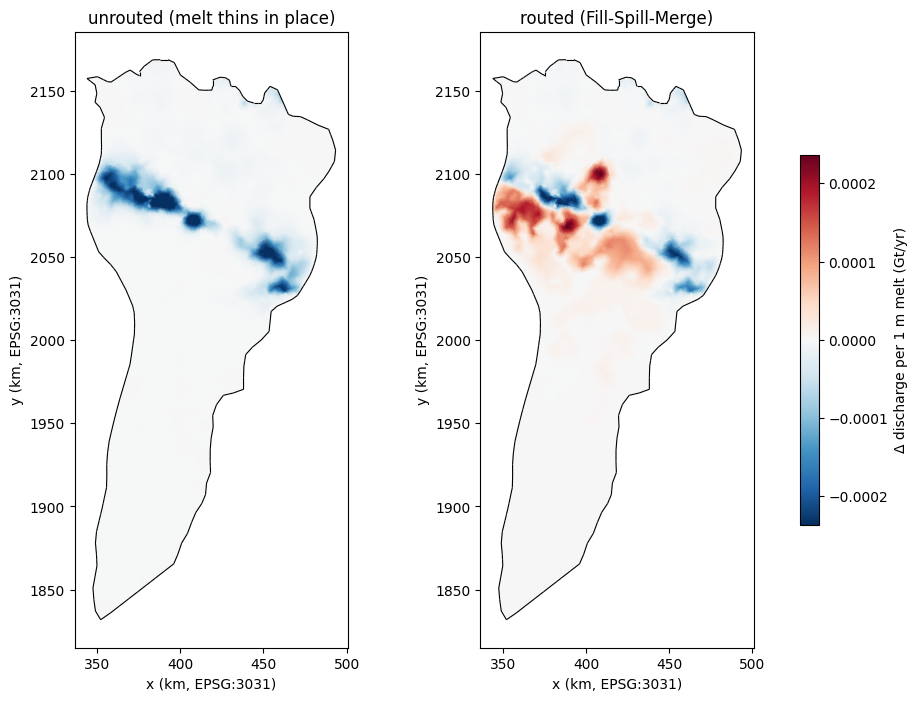

In [8]:
f_r = Function(Q, name="sens_routed"); f_r.dat.data[:] = sens_routed
f_u = Function(Q, name="sens_unrouted"); f_u.dat.data[:] = sens_unrouted
m = float(np.percentile(np.abs(np.concatenate([sens_routed, sens_unrouted])), 99)) or 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, f, title in [(axes[0], f_u, "unrouted (melt thins in place)"),
                     (axes[1], f_r, "routed (Fill-Spill-Merge)")]:
    c = nt.plot_field(f, ax, cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(title)
fig.colorbar(c, ax=axes, shrink=0.6, label="Δ discharge per 1 m melt (Gt/yr)")
plt.show()

We store the sensitivity fields for reuse, alongside the inversion.

In [9]:
os.makedirs("../output", exist_ok=True)
with fd.CheckpointFile("../output/melt_sensitivity.h5", "w") as chk:
    chk.save_mesh(mesh)
    chk.save_function(f_dD)
    chk.save_function(f_r)
    chk.save_function(f_u)
print("saved ../output/melt_sensitivity.h5")

saved ../output/melt_sensitivity.h5


## Recap

Using the calibrated Nivlisen model, we've built a **melt-sensitivity map**. The adjoint gave the grounding-zone flux's response to thinning across the domain. The water routing algorthim reveals where surface meltwater is transported. Combining them shows how much the discharge changes due to melt across the domain.